### Age analysis

We are using EyesClosed only (alpha peaks are usually clearer), predicting fooof_alpha_cf, filtering to rows with a valid alpha peak and decent FOOOF fit, fitting a simple linear regression fooof_alpha_cf ~ age

#### Imports

In [1]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import statsmodels.api as sm

#### Paths  and load the feature table

In [2]:
PROJECT_ROOT = Path(r"C:\Users\maria\Desktop\EEG-special-course")
PROCESSED_ROOT = PROJECT_ROOT / "data_processed"

features_file = PROCESSED_ROOT / "features_pre_ses1.csv"
features = pd.read_csv(features_file)

features.head()

,participant_id,age,condition,alpha_power_8_12,fooof_alpha_cf,fooof_alpha_pw,fooof_alpha_bw,n_epochs_kept,fooof_r2,fooof_error
0,sub-001,60,EyesClosed,-10.268460,10.124218,1.674327,1.942220,91,0.958835,0.087013
1,sub-001,60,EyesOpen,-11.278344,11.232861,0.293344,3.081986,91,0.984296,0.041236
2,sub-002,67,EyesClosed,-10.221186,9.256943,1.711060,2.451334,91,0.964858,0.078536
3,sub-002,67,EyesOpen,-11.416633,8.463996,0.211487,1.000000,91,0.981021,0.053521
4,sub-003,44,EyesClosed,-10.992970,11.359863,1.384598,1.743643,108,0.967652,0.067379


#### Build the age-analysis subset

In [3]:
df_age = features.copy()

# Keep EyesClosed only
df_age = df_age[df_age["condition"] == "EyesClosed"].copy()

# Keep rows with usable age and alpha center frequency
df_age = df_age.dropna(subset=["age", "fooof_alpha_cf"]).copy()

# Recommended FOOOF quality filter
df_age = df_age[
    (df_age["fooof_r2"] >= 0.90) &
    (df_age["fooof_error"] <= 0.12)
].copy()

df_age.shape

(548, 10)

#### Descriptive checks

In [4]:
df_age[["age", "fooof_alpha_cf", "fooof_r2", "fooof_error"]].describe()
df_age.head()

,participant_id,age,condition,alpha_power_8_12,fooof_alpha_cf,fooof_alpha_pw,fooof_alpha_bw,n_epochs_kept,fooof_r2,fooof_error
0,sub-001,60,EyesClosed,-10.268460,10.124218,1.674327,1.942220,91,0.958835,0.087013
2,sub-002,67,EyesClosed,-10.221186,9.256943,1.711060,2.451334,91,0.964858,0.078536
4,sub-003,44,EyesClosed,-10.992970,11.359863,1.384598,1.743643,108,0.967652,0.067379
6,sub-004,24,EyesClosed,-9.989071,10.371027,2.211564,1.433957,88,0.969234,0.079835
8,sub-005,48,EyesClosed,-10.728284,10.190261,1.470827,1.816293,91,0.983473,0.049162


#### Scatter plot

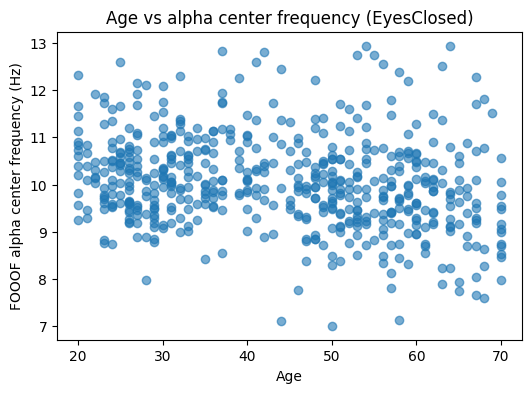

In [5]:
plt.figure(figsize=(6, 4))
plt.scatter(df_age["age"], df_age["fooof_alpha_cf"], alpha=0.6)
plt.xlabel("Age")
plt.ylabel("FOOOF alpha center frequency (Hz)")
plt.title("Age vs alpha center frequency (EyesClosed)")
plt.show()

#### Regression

In [8]:
X = sm.add_constant(df_age["age"].astype(float))
y = df_age["fooof_alpha_cf"].astype(float)

model = sm.OLS(y, X).fit()
print(f"Included recordings: {int(model.nobs)}")
print(f"Estimated alpha center frequency at age 0: {model.params['const']:.3f} Hz")
print(f"Change in alpha center frequency per year of age: {model.params['age']:.4f} Hz/year")
print(f"P-value for age effect: {model.pvalues['age']:.3e}")
print(f"Variance explained (R²): {model.rsquared:.3f}")

Included recordings: 548
Estimated alpha center frequency at age 0: 10.738 Hz
Change in alpha center frequency per year of age: -0.0156 Hz/year
P-value for age effect: 4.501e-08
Variance explained (R²): 0.053


#### Add the fitted line

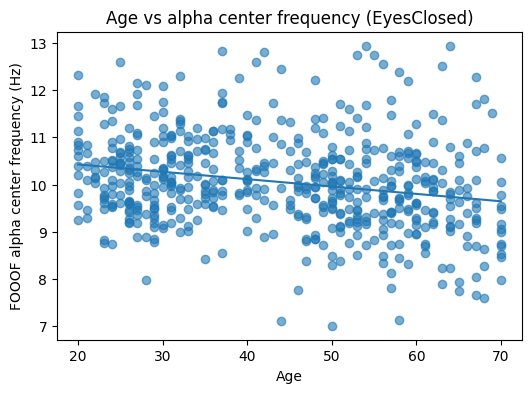

In [7]:
plt.figure(figsize=(6, 4))
plt.scatter(df_age["age"], df_age["fooof_alpha_cf"], alpha=0.6)

x_vals = np.linspace(df_age["age"].min(), df_age["age"].max(), 100)
X_line = sm.add_constant(x_vals)
y_line = model.predict(X_line)

plt.plot(x_vals, y_line)
plt.xlabel("Age")
plt.ylabel("FOOOF alpha center frequency (Hz)")
plt.title("Age vs alpha center frequency (EyesClosed)")
plt.show()